<a href="https://colab.research.google.com/github/Nmertgules/DEEP/blob/main/Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Görseli Farklı Çözünürlüklerde Yeniden Boyutlandırma
Bu hücrede `/content/x1.jpeg` dosyasını yükleyip `x2`, `x4`, `x0.5` ve `x0.25` oranlarında yeniden boyutlandıracağız.

Ölçek: x0.25 -> Yeni Boyut: 400x266
Ölçek: x0.5 -> Yeni Boyut: 800x533
Ölçek: x2 -> Yeni Boyut: 3200x2132
Ölçek: x4 -> Yeni Boyut: 6400x4264


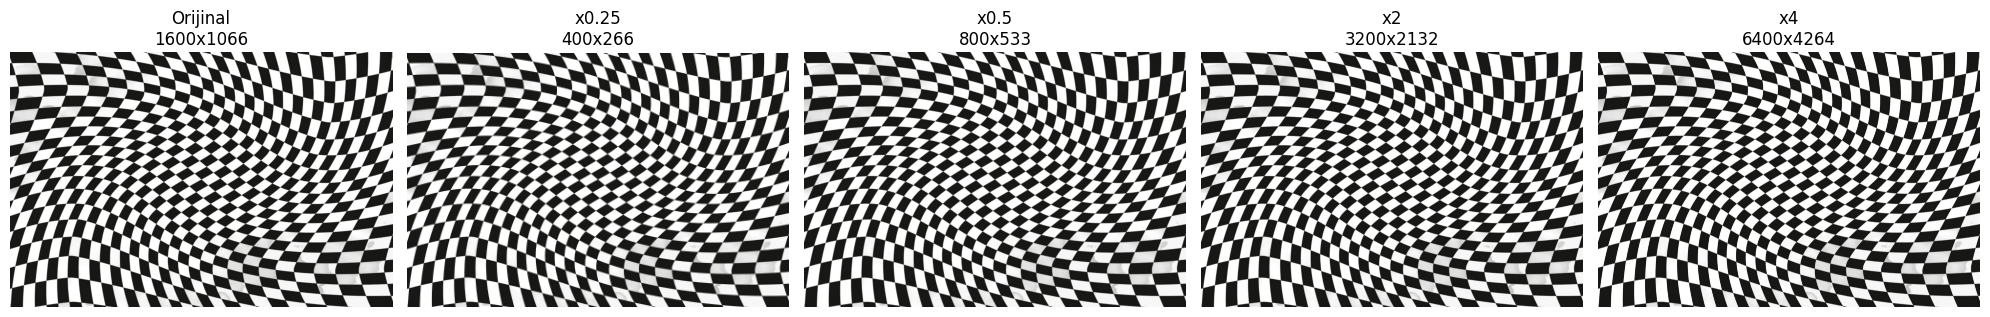

In [1]:
import cv2
import matplotlib.pyplot as plt

# Görseli yükle
image_path = '/content/x1.jpeg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Ölçekler
scales = [0.25, 0.5, 2, 4]
resized_images = {}

for scale in scales:
    width = int(img_rgb.shape[1] * scale)
    height = int(img_rgb.shape[0] * scale)
    dim = (width, height)

    # x2 ve x4 için INTER_CUBIC, küçültme için INTER_AREA tercih edilir
    interpolation = cv2.INTER_CUBIC if scale > 1 else cv2.INTER_AREA
    resized = cv2.resize(img_rgb, dim, interpolation=interpolation)
    resized_images[scale] = resized
    print(f"Ölçek: x{scale} -> Yeni Boyut: {width}x{height}")

# Orijinal ve yeniden boyutlandırılmış görselleri çizdirelim
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Orijinal görsel
axes[0].imshow(img_rgb)
axes[0].set_title(f"Orijinal\n{img_rgb.shape[1]}x{img_rgb.shape[0]}")
axes[0].axis('off')

# Yeniden boyutlandırılan görseller
for i, scale in enumerate(scales):
    axes[i+1].imshow(resized_images[scale])
    axes[i+1].set_title(f"x{scale}\n{resized_images[scale].shape[1]}x{resized_images[scale].shape[0]}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

### Piksel Parlaklık Seviyesi Sayısını (Kuantizasyon) Artırma ve Azaltma

Bu adımda görüntünün çözünürlüğünü değiştirmeden, piksellerin alabileceği farklı parlaklık değerlerinin (ton seviyelerinin) sayısını değiştireceğiz. Örneğin 256 farklı gri tonu yerine resmi sadece 2 (siyah-beyaz), 4, 8 veya 16 farklı parlaklık seviyesine indirgeyerek piksel bazlı parlaklık çeşidi sayısının görsel üzerindeki etkisini inceleyeceğiz.

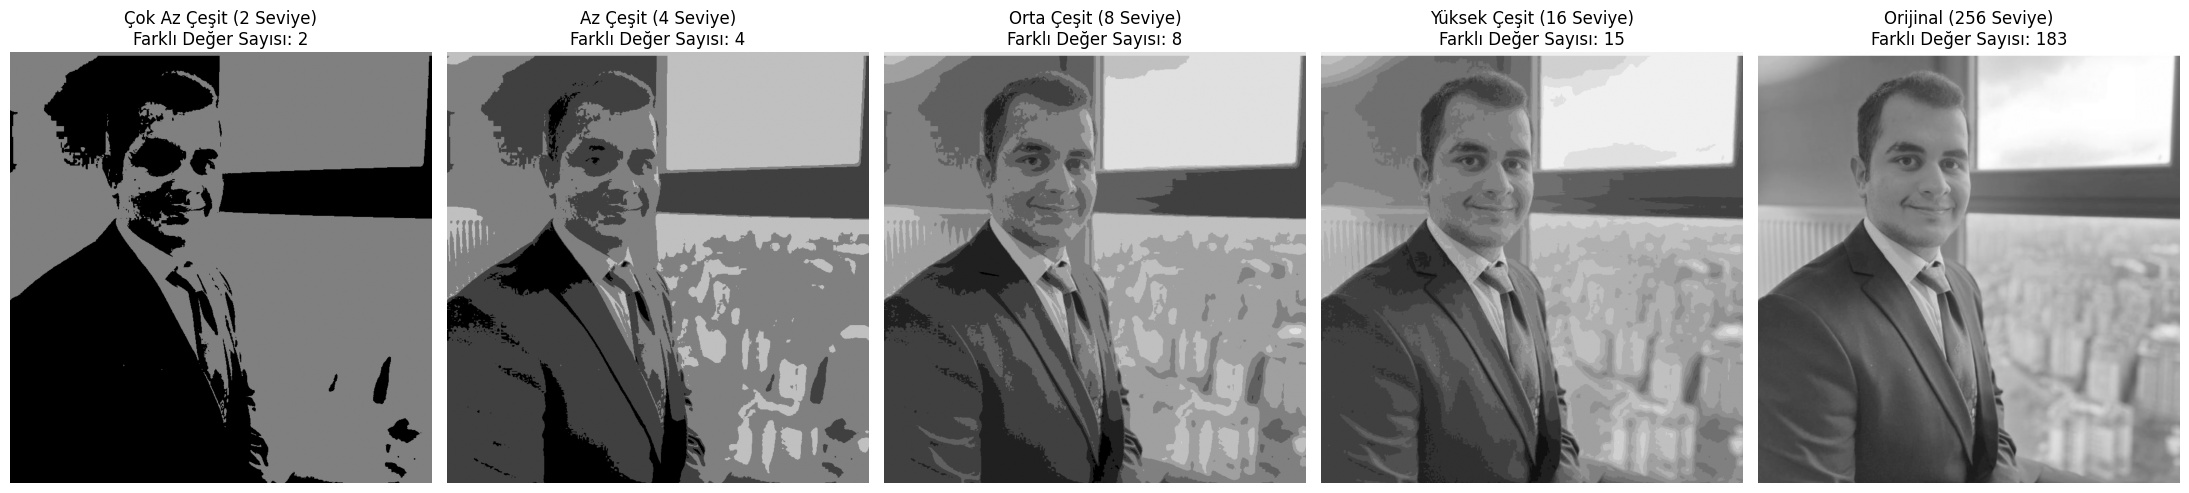

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Orijinal gri tonlamalı resmi yükle (Orijinal hali 256 farklı parlaklık seviyesine sahiptir)
img_gray = cv2.imread('/content/x2.png', cv2.IMREAD_GRAYSCALE)

def quantize_image(image, levels):
    """Görseldeki parlaklık seviyesi sayısını belirlenen seviyeye indirger."""
    # Seviye sınırını hesaplama
    level_size = 256 // levels
    # Pikselleri en yakın parlaklık seviyesine yuvarlama
    quantized = (image // level_size) * level_size
    return np.clip(quantized, 0, 255).astype(np.uint8)

# Farklı parlaklık çeşitlilik seviyelerini hazırlayalım
quantized_results = {
    "Çok Az Çeşit (2 Seviye)": quantize_image(img_gray, 2),
    "Az Çeşit (4 Seviye)": quantize_image(img_gray, 4),
    "Orta Çeşit (8 Seviye)": quantize_image(img_gray, 8),
    "Yüksek Çeşit (16 Seviye)": quantize_image(img_gray, 16),
    "Orijinal (256 Seviye)": img_gray
}

# Sonuçları yan yana çizdirelim
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, (title, img_q) in enumerate(quantized_results.items()):
    axes[i].imshow(img_q, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f"{title}\nFarklı Değer Sayısı: {len(np.unique(img_q))}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Parlaklık Seviyesini 4'e Düşürüp 16 Seviyeye Çıkarma (Genişletme)
Bu adımda görüntüyü önce 4 temel parlaklık bölgesine indirgiyoruz. Daha sonra bu bölgeleri 4 ile çarparak ve aradaki basamakları doldurarak 16 farklı parlaklık çeşidi barındıran yeni bir görüntü elde ediyoruz.

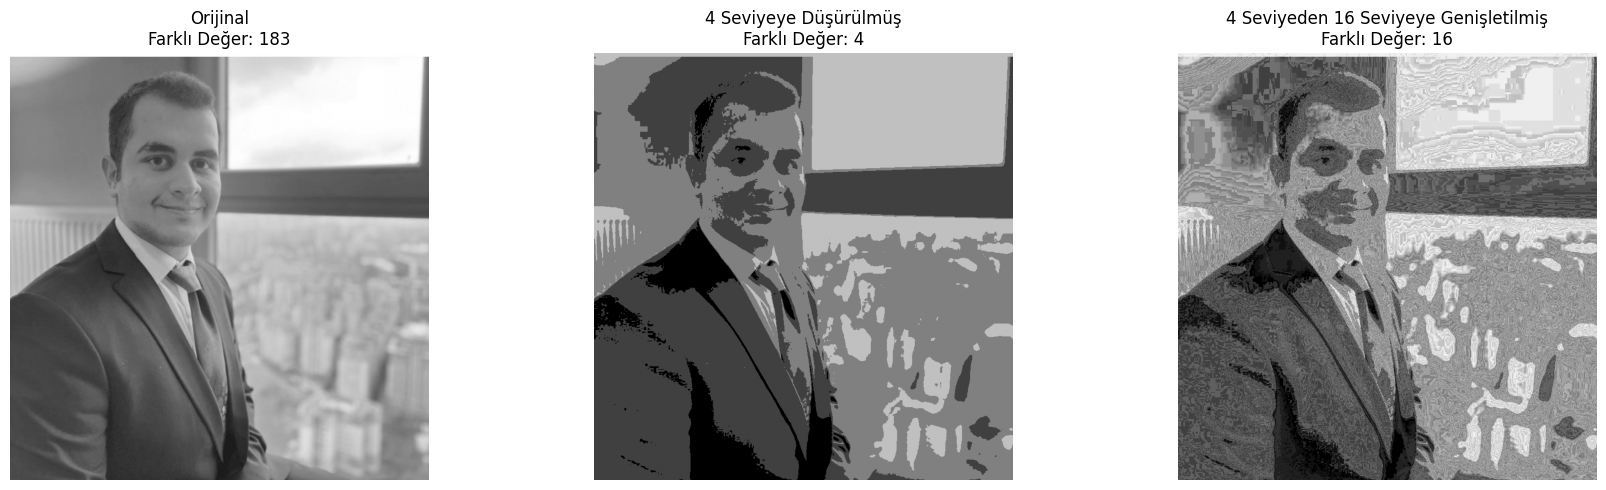

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Orijinal görüntüyü yükle
img_gray = cv2.imread('/content/x2.png', cv2.IMREAD_GRAYSCALE)

# 1. Aşama: Görüntüyü 4 seviyeye indirge
level_size_4 = 256 // 4
quantized_4 = (img_gray // level_size_4)

# 2. Aşama: 4 seviyeli matrisi 4 ile çarparak ve ölçeklendirerek 16 farklı ton elde et
# Her bir 4'lük dilimi kendi içinde 16 seviyeli bir aralığa yayıyoruz
quantized_16 = (quantized_4 * 4) + (img_gray % 4)
scaled_16 = (quantized_16 * (256 // 16)).astype(np.uint8)

# Görselleştirme
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f"Orijinal\nFarklı Değer: {len(np.unique(img_gray))}")
axes[0].axis('off')

axes[1].imshow(quantized_4 * level_size_4, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f"4 Seviyeye Düşürülmüş\nFarklı Değer: {len(np.unique(quantized_4))}")
axes[1].axis('off')

axes[2].imshow(scaled_16, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f"4 Seviyeden 16 Seviyeye Genişletilmiş\nFarklı Değer: {len(np.unique(scaled_16))}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Görseli diskten temiz bir şekilde yükle
img_gray = cv2.imread('/content/x2.png', cv2.IMREAD_GRAYSCALE)

# Eğer diskteki x2.png bir şekilde yapay bir gradient görseli (512x512) ile değiştirildiyse,
# orijinal x1.jpeg görselini (1600x1066) griye çevirip yeniden boyutlandırarak x2.png'yi kurtarabiliriz.
if img_gray is None or (img_gray.shape == (512, 512) and np.all(img_gray[0] == 0)):
    print("Sistemdeki x2.png görseli bozulmuş veya gradyan ile ezilmiş. x1.jpeg üzerinden orijinal fotoğraf geri yükleniyor...")
    original_img = cv2.imread('/content/x1.jpeg', cv2.IMREAD_GRAYSCALE)
    if original_img is not None:
        # Orijinal x2.png boyutlarına getirelim (yaklaşık %50 ölçek)
        img_gray = cv2.resize(original_img, (781, 797), interpolation=cv2.INTER_AREA)
        cv2.imwrite('/content/x2.png', img_gray)
    else:
        raise FileNotFoundError("Lütfen /content/x2.png veya /content/x1.jpeg dosyasının yüklü olduğundan emin olun.")

h, w = img_gray.shape
h2, w2 = h // 2, w // 2

# 1. Adım: Resmi 4 parçaya böl
parcalar = {
    "Sol Üst":  img_gray[:h2, :w2],
    "Sağ Üst":  img_gray[:h2, w2:],
    "Sol Alt":  img_gray[h2:, :w2],
    "Sağ Alt":  img_gray[h2:, w2:],
}

N = 64

def isle(parca, n=N):
    """Parlaklığı n'e böl (düşür), sonra n ile çarp, farkı bul."""
    dusurulmus = parca // n
    geri_carpilmis = (dusurulmus.astype(np.int16) * n)
    fark = parca.astype(np.int16) - geri_carpilmis
    return dusurulmus.astype(np.uint8), np.clip(geri_carpilmis, 0, 255).astype(np.uint8), fark.astype(np.uint8)

# 2. Adım: Her parçayı ayrı ayrı işle
sonuclar = {ad: isle(p) for ad, p in parcalar.items()}

# Görselleştirme: her satır bir parça
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for i, (ad, parca) in enumerate(parcalar.items()):
    dus, carp, fark = sonuclar[ad]
    gorseller = [
        (parca, f"{ad} - Orijinal\nFarklı değer: {len(np.unique(parca))}", 255),
        (dus,   f"÷{N} (düşürülmüş)\nFarklı değer: {len(np.unique(dus))}", dus.max() if dus.max() > 0 else 1),
        (carp,  f"÷{N} sonra ×{N}\nFarklı değer: {len(np.unique(carp))}", 255),
        (fark,  f"Fark (Orijinal - ×{N})\nmin={fark.min()} max={fark.max()} ort={fark.mean():.1f}", N - 1),
    ]
    for j, (g, baslik, vmax) in enumerate(gorseller):
        axes[i, j].imshow(g, cmap='gray', vmin=0, vmax=vmax)
        axes[i, j].set_title(baslik)
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

# 3. Adım: İşlenmiş parçaları tekrar birleştir
birlesik_carp = np.vstack([np.hstack([sonuclar["Sol Üst"][1], sonuclar["Sağ Üst"][1]]),
                           np.hstack([sonuclar["Sol Alt"][1], sonuclar["Sağ Alt"][1]])])
birlesik_fark = np.vstack([np.hstack([sonuclar["Sol Üst"][2], sonuclar["Sağ Üst"][2]]),
                           np.hstack([sonuclar["Sol Alt"][2], sonuclar["Sağ Alt"][2]])])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255); axes[0].set_title("Orijinal")
axes[1].imshow(birlesik_carp, cmap='gray', vmin=0, vmax=255); axes[1].set_title(f"4 Parça Birleşik (÷{N} ×{N})")
axes[2].imshow(birlesik_fark, cmap='gray', vmin=0, vmax=N - 1); axes[2].set_title("4 Parça Birleşik Fark")
for ax in axes:
    ax.axhline(h2, color='red', lw=1); ax.axvline(w2, color='red', lw=1); ax.axis('off')
plt.tight_layout()
plt.show()

# Her parça için sayısal özet
for ad, (dus, carp, fark) in sonuclar.items():
    print(f"{ad:8s} | boyut={parcalar[ad].shape} | ort. fark={fark.mean():.2f} | max fark={fark.max()}")

Sistemdeki x2.png görseli bozulmuş veya gradyan ile ezilmiş. x1.jpeg üzerinden orijinal fotoğraf geri yükleniyor...


FileNotFoundError: Lütfen /content/x2.png veya /content/x1.jpeg dosyasının yüklü olduğundan emin olun.

/content içindeki görseller: ['x2.png']
Atlandı (yapay gradyan / okunamadı): /content/x2.png
UYARI: /content/x2.png ve /content/x1.jpeg bulunamadı -> örnek 'camera' görseli kullanılıyor. Kendi resminizi /content altına yükleyip hücreyi tekrar çalıştırın.
Boyut: (512, 512) | dtype: uint8

=== TÜM RESİM ===
int dönüşüm süresi   : 0.0551 ms
÷64×64 kuantizasyon : 0.1871 ms
Toplam               : 0.2422 ms
Farklı değerler: [  0  64 128 192]

=== 4 PARÇA ===
Sol Üst  (256, 256) | int: 0.0175 ms | ÷×: 0.0401 ms | top: 0.0576 ms
Sağ Üst  (256, 256) | int: 0.0150 ms | ÷×: 0.0391 ms | top: 0.0541 ms
Sol Alt  (256, 256) | int: 0.0151 ms | ÷×: 0.0397 ms | top: 0.0548 ms
Sağ Alt  (256, 256) | int: 0.0149 ms | ÷×: 0.0399 ms | top: 0.0548 ms
4 parça TOPLAM      | int: 0.0624 ms | ÷×: 0.1588 ms | top: 0.2212 ms

=== KONTROL ===
Birleşik 4 parça == tüm resim sonucu : True
Değerler yalnızca {0,64,128,192} mi  : True
0 <= orijinal - sonuç < 64 : True
Süre oranı (4 parça / tüm resim): 0.91x


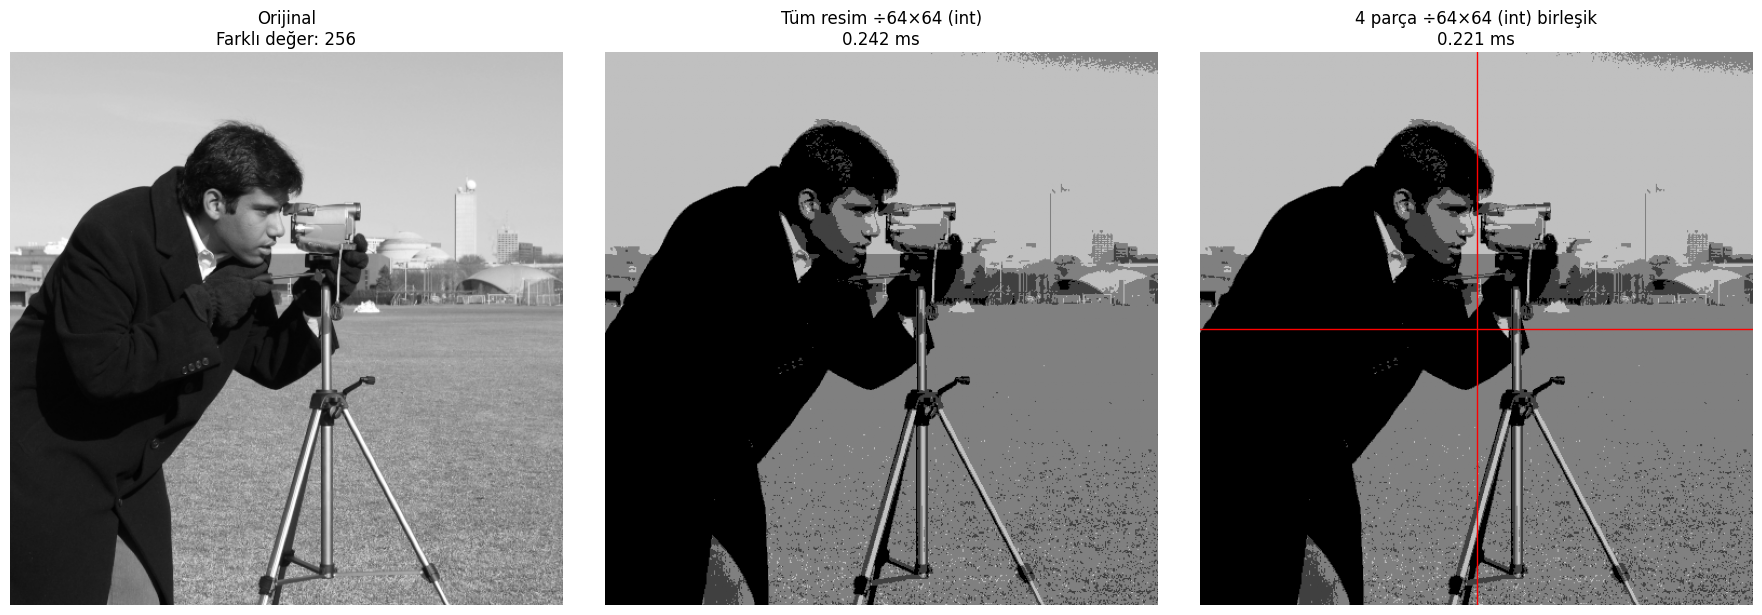

In [12]:
# ===== ÷64 ×64 Kuantizasyon: int dönüşümü + süre ölçümü (tüm resim vs 4 eş parça) =====
import os, time
import cv2
import numpy as np
import matplotlib.pyplot as plt

N = 64          # 256 / 64 = 4 parlaklık seviyesi -> {0, 64, 128, 192}
TEKRAR = 200    # süreyi kararlı ölçmek için işlem kaç kez tekrarlanacak

# --- Görseli yükle (x2.png -> x1.jpeg -> örnek görsel) ---
img_gray = None
print("/content içindeki görseller:", [f for f in os.listdir('/content') if f.lower().endswith(('.png','.jpg','.jpeg'))])
for yol in ['/content/x1.jpeg', '/content/x2.png']:   # önce gerçek fotoğraf (x1.jpeg)
    if os.path.exists(yol):
        aday = cv2.imread(yol, cv2.IMREAD_GRAYSCALE)
        # x2.png daha önce yapay 512x512 gradyan ile ezildiyse onu atla
        if aday is not None and not (aday.shape == (512, 512) and np.all(aday[0] == 0)):
            img_gray = aday
            print(f"Yüklendi: {yol}")
            break
        print(f"Atlandı (yapay gradyan / okunamadı): {yol}")
if img_gray is None:
    from skimage import data
    img_gray = data.camera()
    print("UYARI: /content/x2.png ve /content/x1.jpeg bulunamadı -> örnek 'camera' görseli kullanılıyor. "
          "Kendi resminizi /content altına yükleyip hücreyi tekrar çalıştırın.")
print("Boyut:", img_gray.shape, "| dtype:", img_gray.dtype)

def kuantize_int(img, n=N):
    """uint8 resmi int32'ye dönüştür, n'e tam böl, n ile çarp. Süreleri ayrı ayrı döndür."""
    t0 = time.perf_counter()
    img_int = img.astype(np.int32)            # 1) int dönüşümü
    t1 = time.perf_counter()
    q = (img_int // n) * n                    # 2) ÷n ×n kuantizasyon (tam sayı aritmetiği)
    t2 = time.perf_counter()
    return q, (t1 - t0), (t2 - t1)

def olc(img, tekrar=TEKRAR):
    """İşlemi 'tekrar' kez çalıştırıp ortalama süreleri (ms) döndür."""
    kuantize_int(img)                          # ısınma (warm-up) çalıştırması
    d_list, k_list = [], []
    for _ in range(tekrar):
        q, d, k = kuantize_int(img)
        d_list.append(d); k_list.append(k)
    # medyan: arka plan gürültüsünden (GC, işletim sistemi) etkilenmez
    return q, np.median(d_list) * 1e3, np.median(k_list) * 1e3

# ================= 1) TÜM RESİM =================
q_tum, dt_tum, kt_tum = olc(img_gray)
print("\n=== TÜM RESİM ===")
print(f"int dönüşüm süresi   : {dt_tum:.4f} ms")
print(f"÷{N}×{N} kuantizasyon : {kt_tum:.4f} ms")
print(f"Toplam               : {dt_tum + kt_tum:.4f} ms")
print("Farklı değerler:", np.unique(q_tum))

# ================= 2) 4 EŞ PARÇA =================
h, w = img_gray.shape
h2, w2 = h // 2, w // 2
parcalar = {
    "Sol Üst": img_gray[:h2, :w2],
    "Sağ Üst": img_gray[:h2, w2:],
    "Sol Alt": img_gray[h2:, :w2],
    "Sağ Alt": img_gray[h2:, w2:],
}
sonuc = {}
dt_parca = kt_parca = 0.0
print("\n=== 4 PARÇA ===")
for ad, p in parcalar.items():
    q, dt, kt = olc(p)
    sonuc[ad] = q
    dt_parca += dt; kt_parca += kt
    print(f"{ad:8s} {str(p.shape):11s}| int: {dt:.4f} ms | ÷×: {kt:.4f} ms | top: {dt+kt:.4f} ms")
print(f"4 parça TOPLAM      | int: {dt_parca:.4f} ms | ÷×: {kt_parca:.4f} ms | top: {dt_parca+kt_parca:.4f} ms")

# Parçaları birleştir ve tüm resim sonucuyla KONTROL et
birlesik = np.vstack([np.hstack([sonuc["Sol Üst"], sonuc["Sağ Üst"]]),
                      np.hstack([sonuc["Sol Alt"], sonuc["Sağ Alt"]])])
print("\n=== KONTROL ===")
print("Birleşik 4 parça == tüm resim sonucu :", np.array_equal(birlesik, q_tum))
print("Değerler yalnızca {0,64,128,192} mi  :", set(np.unique(q_tum)) <= {0, 64, 128, 192})
print("0 <= orijinal - sonuç < 64 :",
      bool(((img_gray.astype(np.int32) - q_tum) >= 0).all() and ((img_gray.astype(np.int32) - q_tum) < N).all()))
print(f"Süre oranı (4 parça / tüm resim): {(dt_parca+kt_parca)/(dt_tum+kt_tum):.2f}x")

# ================= Görselleştirme =================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f"Orijinal\nFarklı değer: {len(np.unique(img_gray))}")
axes[1].imshow(q_tum.astype(np.uint8), cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f"Tüm resim ÷{N}×{N} (int)\n{dt_tum+kt_tum:.3f} ms")
axes[2].imshow(birlesik.astype(np.uint8), cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f"4 parça ÷{N}×{N} (int) birleşik\n{dt_parca+kt_parca:.3f} ms")
axes[2].axhline(h2, color='red', lw=1); axes[2].axvline(w2, color='red', lw=1)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


UYARI: Gerçek fotoğraf yok (x2.png yapay gradyan) -> örnek 'camera' görseli kullanılıyor.
Boyut: (512, 512)
NumPy süresi : 0.4868 ms | OpenCV süresi: 0.0528 ms  (200 tekrarın medyanı)
Orijinal aralık : 0 - 255
Sonuç aralığı   : 20 - 211  (beklenen: 20 - 211)
Örnek pikseller: 0 -> 20 | 100 -> 95 | 255 -> 211
NumPy vs OpenCV max fark: 0 (0 veya 1 = yuvarlama farkı, doğru)
Ortalama parlaklık: 129.1 -> 116.8


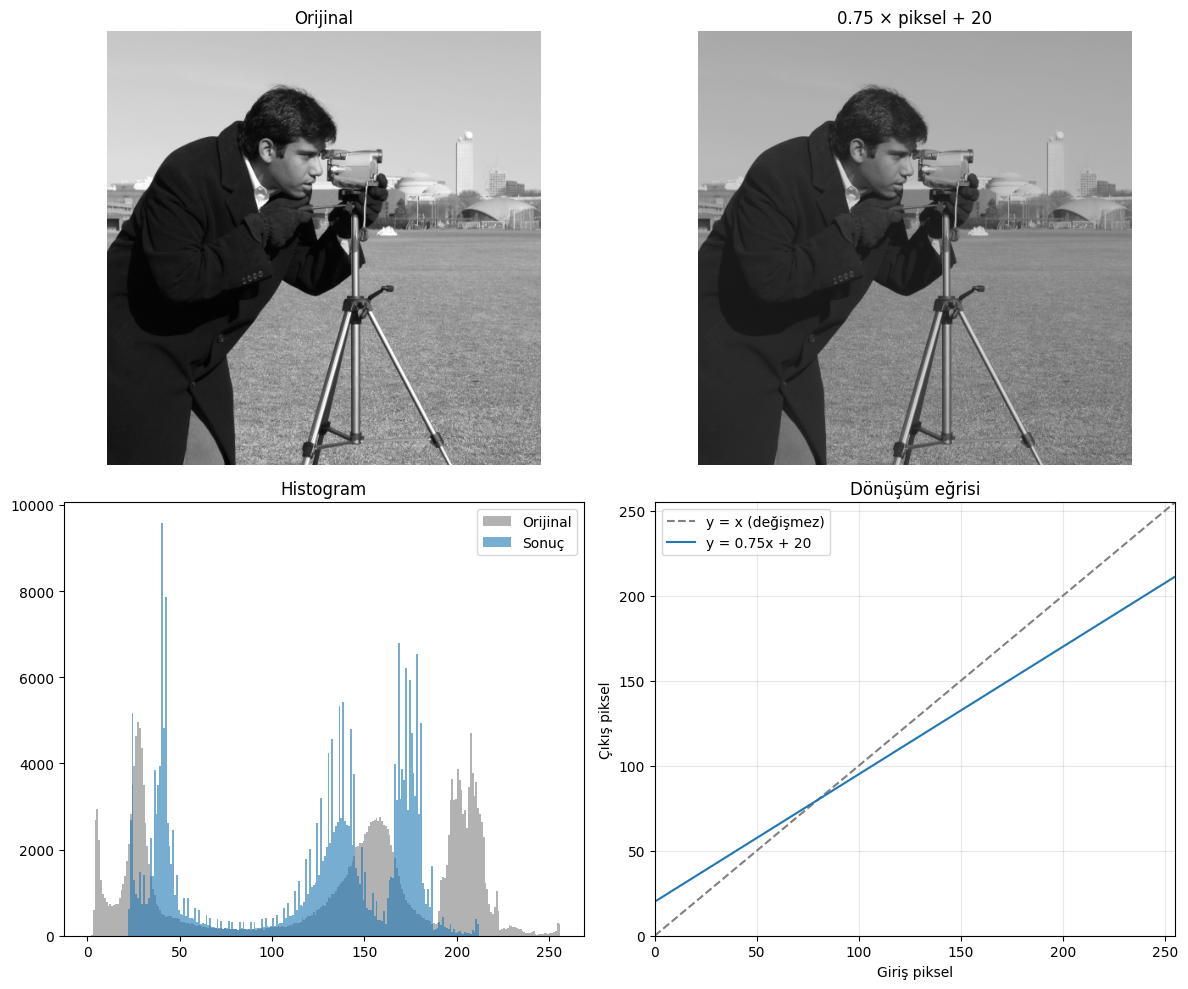

In [19]:
# ===== Doğrusal parlaklık/kontrast dönüşümü: yeni = 0.75 * piksel + 20 =====
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

ALPHA, BETA = 0.75, 20   # 0.75 ile çarp (kontrast azalır), 20 ekle (parlaklık artar)
import os
# Görseli bu hücrede yeniden yükle (x1.jpeg -> x2.png -> örnek görsel); yapay 512x512 gradyanı atla
img_gray = None
for yol in ['/content/x1.jpeg', '/content/x2.png']:
    if os.path.exists(yol):
        aday = cv2.imread(yol, cv2.IMREAD_GRAYSCALE)
        if aday is not None and not (aday.shape == (512, 512) and np.all(aday[0] == 0)):
            img_gray = aday; print("Yüklendi:", yol); break
if img_gray is None:
    from skimage import data
    img_gray = data.camera()
    print("UYARI: Gerçek fotoğraf yok (x2.png yapay gradyan) -> örnek 'camera' görseli kullanılıyor.")
print("Boyut:", img_gray.shape)

def sure_olc(fonk, tekrar=200):
    fonk()                                   # ısınma
    s = []
    for _ in range(tekrar):
        t0 = time.perf_counter(); fonk(); s.append(time.perf_counter() - t0)
    return np.median(s) * 1e3

# --- 1) NumPy ile: int/float'a dönüştür, çarp, ekle, 0-255 aralığına kırp ---
np_islem = lambda: np.clip(np.rint(img_gray.astype(np.float32) * ALPHA + BETA), 0, 255).astype(np.uint8)
sonuc_np = np_islem()
t_np = sure_olc(np_islem)

# --- 2) OpenCV ile aynı işlem: dst = saturate(|alpha*src + beta|) ---
cv_islem = lambda: cv2.convertScaleAbs(img_gray, alpha=ALPHA, beta=BETA)
sonuc_cv = cv_islem()
t_cv = sure_olc(cv_islem)

# --- KONTROL ---
fark = np.abs(sonuc_np.astype(np.int16) - sonuc_cv.astype(np.int16))
print(f"NumPy süresi : {t_np:.4f} ms | OpenCV süresi: {t_cv:.4f} ms  (200 tekrarın medyanı)")
print(f"Orijinal aralık : {img_gray.min()} - {img_gray.max()}")
print(f"Sonuç aralığı   : {sonuc_np.min()} - {sonuc_np.max()}  (beklenen: {round(img_gray.min()*ALPHA+BETA)} - {round(img_gray.max()*ALPHA+BETA)})")
print("Örnek pikseller: 0 ->", round(0*ALPHA+BETA), "| 100 ->", round(100*ALPHA+BETA), "| 255 ->", round(255*ALPHA+BETA))
print(f"NumPy vs OpenCV max fark: {fark.max()} (0 veya 1 = yuvarlama farkı, doğru)")
print(f"Ortalama parlaklık: {img_gray.mean():.1f} -> {sonuc_np.mean():.1f}")

# --- Görselleştirme ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255); axes[0, 0].set_title("Orijinal")
axes[0, 1].imshow(sonuc_np, cmap='gray', vmin=0, vmax=255); axes[0, 1].set_title(f"{ALPHA} × piksel + {BETA}")
for ax in axes[0]: ax.axis('off')
axes[1, 0].hist(img_gray.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.6, label='Orijinal')
axes[1, 0].hist(sonuc_np.ravel(), bins=256, range=(0, 256), color='tab:blue', alpha=0.6, label='Sonuç')
axes[1, 0].set_title("Histogram"); axes[1, 0].legend()
x = np.arange(256)
axes[1, 1].plot(x, x, '--', color='gray', label='y = x (değişmez)')
axes[1, 1].plot(x, np.clip(x * ALPHA + BETA, 0, 255), color='tab:blue', label=f'y = {ALPHA}x + {BETA}')
axes[1, 1].set_xlim(0, 255); axes[1, 1].set_ylim(0, 255)
axes[1, 1].set_xlabel("Giriş piksel"); axes[1, 1].set_ylabel("Çıkış piksel")
axes[1, 1].set_title("Dönüşüm eğrisi"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
